# Polygon-Mean SIF Regression: XGBoost and Random Forest

Predict `target_modis_sif` from polygon-mean Sentinel-2 indices, FAPAR, PAR, APAR, active crop percentage and cyclical month variables.

The notebook uses one grouped 80/20 train-test split. All rows from the same `Delta_Date` remain in the same split to reduce acquisition-date leakage. Both models use exactly the same rows.

## 1. Imports and Configuration

In [1]:
from pathlib import Path
import json
import math
import random

import altair as alt
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedGroupKFold
import xgboost as xgb

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
alt.data_transformers.disable_max_rows()

# Change this to the path shown under the Kaggle Input panel.
KAGGLE_DATA_PATH = Path(
    '/kaggle/input/datasets/vishalt11/pmeans-sif-data/model_data_pmeans_6tiles_with_modis_sif_fapar_par_cleaned.csv'
)
LOCAL_DATA_PATH = Path(
    'data/pmeans_model_data/'
    'model_data_pmeans_6tiles_with_modis_sif_fapar_par_cleaned.csv'
)
DATA_PATH = KAGGLE_DATA_PATH if KAGGLE_DATA_PATH.exists() else LOCAL_DATA_PATH

OUTPUT_DIR = (
    Path('/kaggle/working/pmeans_tabular_models')
    if Path('/kaggle/working').exists()
    else Path('data/pmeans_model_data/tabular_model_results')
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'target_modis_sif'
BASE_FEATURE_COLS = [
    'mean_ndvi',
    'mean_nirv',
    'mean_fapar',
    'mean_par',
    'apar',
    'active_crop_pct',
]
MONTH_FEATURE_COLS = ['month_sin', 'month_cos']
FEATURE_COLS = BASE_FEATURE_COLS + MONTH_FEATURE_COLS

print('Data path:', DATA_PATH)
print('Output directory:', OUTPUT_DIR)
print('Features:', FEATURE_COLS)

Data path: /kaggle/input/datasets/vishalt11/pmeans-sif-data/model_data_pmeans_6tiles_with_modis_sif_fapar_par_cleaned.csv
Output directory: /kaggle/working/pmeans_tabular_models
Features: ['mean_ndvi', 'mean_nirv', 'mean_fapar', 'mean_par', 'apar', 'active_crop_pct', 'month_sin', 'month_cos']


## 2. Load and Prepare the Dataset

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'{DATA_PATH} does not exist. Change KAGGLE_DATA_PATH in the '
        'configuration cell to the mounted Kaggle dataset path.'
    )

df = pd.read_csv(DATA_PATH, low_memory=False)
df['source_csv_row'] = np.arange(len(df), dtype=np.int64)

required_cols = [TARGET_COL, 'Delta_Date', *BASE_FEATURE_COLS]
missing_cols = [column for column in required_cols if column not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

df['Delta_Date'] = pd.to_datetime(df['Delta_Date'], errors='coerce')
df['month'] = df['Delta_Date'].dt.month

# Trees do not require feature scaling. Month is represented cyclically.
month_angle = 2.0 * np.pi * df['month'] / 12.0
df['month_sin'] = np.sin(month_angle)
df['month_cos'] = np.cos(month_angle)

if 'final_check_modis_sif' in df.columns:
    before_accept_filter = len(df)
    accepted = df['final_check_modis_sif'].astype(str).str.lower().eq('accept')
    df = df.loc[accepted].copy()
    print(
        'Rows removed by final_check_modis_sif:',
        before_accept_filter - len(df),
    )

numeric_cols = [TARGET_COL, *FEATURE_COLS]
for column in numeric_cols:
    df[column] = pd.to_numeric(df[column], errors='coerce')
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

missing_summary = df[required_cols + MONTH_FEATURE_COLS].isna().sum()
display(missing_summary.to_frame('n_missing'))

before_complete_case_filter = len(df)
model_df = df.dropna(
    subset=[TARGET_COL, 'Delta_Date', *FEATURE_COLS]
).copy()
model_df = model_df.reset_index(drop=True)

print('Original rows:', before_complete_case_filter)
print('Model-ready complete rows:', len(model_df))
print('Rows removed for missing required values:', before_complete_case_filter - len(model_df))
display(model_df[[TARGET_COL, *FEATURE_COLS]].describe().T)

Rows removed by final_check_modis_sif: 94


,n_missing
target_modis_sif,0
Delta_Date,0
mean_ndvi,0
mean_nirv,0
mean_fapar,0
mean_par,0
apar,0
active_crop_pct,0
month_sin,0
month_cos,0


Original rows: 26144
Model-ready complete rows: 26144
Rows removed for missing required values: 0


,count,mean,std,min,25%,50%,75%,max
target_modis_sif,26144.0,0.324493,0.223149,-0.338701,1.487387e-01,0.312502,0.478720,1.520325
mean_ndvi,26144.0,0.644140,0.130509,0.178154,5.534348e-01,0.653666,0.740606,0.956903
mean_nirv,26144.0,0.205819,0.070277,0.027990,1.448333e-01,0.211884,0.259892,0.566532
mean_fapar,26144.0,0.600865,0.139533,0.117833,5.052703e-01,0.605333,0.695435,0.928211
mean_par,26144.0,107.949054,37.618033,5.482392,7.777921e+01,112.907610,140.052933,174.256073
apar,26144.0,67.073109,32.051656,1.445254,4.029411e+01,65.596265,91.506025,157.770252
active_crop_pct,26144.0,0.865063,0.241046,0.000000,8.308222e-01,0.999029,1.000000,1.000000
month_sin,26144.0,0.430649,0.535164,-0.500000,1.224647e-16,0.500000,0.866025,1.000000
month_cos,26144.0,-0.587850,0.427307,-1.000000,-8.660254e-01,-0.866025,-0.500000,0.500000


## 3. Grouped 80/20 Train-Test Split

`Delta_Date` is the grouping variable. The split approximately balances month, measurement mode and broad target-value bins while keeping each acquisition date entirely in train or test.

In [3]:
target_bin = pd.qcut(
    model_df[TARGET_COL].rank(method='first'),
    q=5,
    labels=False,
)
if 'Metadata.MeasurementMode' in model_df.columns:
    mode_str = (
        pd.to_numeric(model_df['Metadata.MeasurementMode'], errors='coerce')
        .fillna(-1)
        .astype(int)
        .astype(str)
    )
else:
    mode_str = pd.Series('unknown', index=model_df.index)

split_strata = (
    model_df['month'].astype(int).astype(str)
    + '_m' + mode_str
    + '_y' + target_bin.astype(int).astype(str)
)
split_groups = model_df['Delta_Date'].dt.strftime('%Y-%m-%d')

splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)
train_idx, test_idx = next(
    splitter.split(model_df, y=split_strata, groups=split_groups)
)

train_df = model_df.iloc[train_idx].copy().reset_index(drop=True)
test_df = model_df.iloc[test_idx].copy().reset_index(drop=True)

shared_dates = set(train_df['Delta_Date'].dt.date) & set(test_df['Delta_Date'].dt.date)
if shared_dates:
    raise RuntimeError(f'Train and test share {len(shared_dates)} Delta_Date values')

print(f'Train rows: {len(train_df):,} ({len(train_df) / len(model_df):.1%})')
print(f'Test rows:  {len(test_df):,} ({len(test_df) / len(model_df):.1%})')
print('Train dates:', train_df['Delta_Date'].nunique())
print('Test dates:', test_df['Delta_Date'].nunique())
print('Shared dates:', len(shared_dates))

split_balance = pd.concat(
    [
        train_df.assign(split='train'),
        test_df.assign(split='test'),
    ],
    ignore_index=True,
).groupby(['split', 'month'], as_index=False).agg(
    n=(TARGET_COL, 'size'),
    target_mean=(TARGET_COL, 'mean'),
    target_sd=(TARGET_COL, 'std'),
)
display(split_balance)

Train rows: 20,255 (77.5%)
Test rows:  5,889 (22.5%)
Train dates: 96
Test dates: 23
Shared dates: 0


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,split,month,n,target_mean,target_sd
0,test,2,58,0.136370,0.098956
1,test,3,807,0.107989,0.086715
2,test,4,1671,0.247742,0.155654
3,test,5,763,0.412826,0.195524
4,test,6,2111,0.513905,0.187051
5,test,7,479,0.358181,0.181847
6,train,2,1235,0.066521,0.085379
7,train,3,3853,0.124339,0.111681
8,train,4,4262,0.288060,0.163482
9,train,5,4091,0.435384,0.200662


## 4. Training Matrices

In [4]:
X_train = train_df[FEATURE_COLS].to_numpy(dtype=np.float32)
y_train = train_df[TARGET_COL].to_numpy(dtype=np.float32)
X_test = test_df[FEATURE_COLS].to_numpy(dtype=np.float32)
y_test = test_df[TARGET_COL].to_numpy(dtype=np.float32)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test:', X_test.shape, 'y_test:', y_test.shape)

X_train: (20255, 8) y_train: (20255,)
X_test: (5889, 8) y_test: (5889,)


## 5. Train XGBoost

Fixed settings are used so the untouched test set is not used for model selection.

In [5]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=1.00,
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
xgb_test_pred = xgb_model.predict(X_test).astype(np.float64)
print('XGBoost training complete')

XGBoost training complete


## 6. Train Random Forest

In [6]:
rf_model = RandomForestRegressor(
    n_estimators=700,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features=0.80,
    bootstrap=True,
    random_state=SEED,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
rf_test_pred = rf_model.predict(X_test).astype(np.float64)
print('Random Forest training complete')

Random Forest training complete


## 7. Test Metrics

In [7]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    residual = y_pred - y_true
    slope, intercept = np.polyfit(y_true, y_pred, deg=1)
    pearson_r = np.corrcoef(y_true, y_pred)[0, 1]
    return {
        'n': int(len(y_true)),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'bias': float(residual.mean()),
        'r2': float(r2_score(y_true, y_pred)),
        'intercept': float(intercept),
        'slope': float(slope),
        'pearson_r': float(pearson_r),
    }

metrics = {
    'XGBoost': regression_metrics(y_test, xgb_test_pred),
    'Random Forest': regression_metrics(y_test, rf_test_pred),
}
metrics_df = pd.DataFrame(metrics).T.rename_axis('model').reset_index()
display(metrics_df)
metrics_df.to_csv(OUTPUT_DIR / 'test_metrics.csv', index=False)

,model,n,rmse,mae,bias,r2,intercept,slope,pearson_r
0,XGBoost,5889.0,0.164984,0.127414,0.012545,0.452763,0.201705,0.464556,0.675340
1,Random Forest,5889.0,0.168930,0.131143,0.014588,0.426271,0.210834,0.444494,0.656486


## 8. Save Test Predictions

In [8]:
metadata_cols = [
    column
    for column in [
        'source_csv_row', 'sif_row_id', 'Delta_Date', 'sif_year',
        'month', 'mgrs_tile', 'state', 'Metadata.MeasurementMode',
        'Quality_Flag', 'date_align', 'Latitude', 'Longitude',
    ]
    if column in test_df.columns
]

test_predictions = test_df[metadata_cols].copy()
test_predictions['observed_sif'] = y_test
test_predictions['predicted_sif_xgboost'] = xgb_test_pred
test_predictions['predicted_sif_random_forest'] = rf_test_pred
test_predictions['residual_xgboost'] = xgb_test_pred - y_test
test_predictions['residual_random_forest'] = rf_test_pred - y_test
test_predictions.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)
display(test_predictions.head())

,source_csv_row,sif_row_id,Delta_Date,sif_year,month,mgrs_tile,state,Metadata.MeasurementMode,Quality_Flag,date_align,Latitude,Longitude,observed_sif,predicted_sif_xgboost,predicted_sif_random_forest,residual_xgboost,residual_random_forest
0,658,659,2019-06-21,2019,6,32UNA,BAYERN,0,0,inrange,49.652527,9.832703,0.531230,0.589436,0.628049,0.058206,0.096818
1,659,660,2019-06-21,2019,6,32UNA,BAYERN,0,0,inrange,49.672302,9.824463,0.632170,0.432754,0.406543,-0.199416,-0.225627
2,660,661,2019-06-21,2019,6,32UNA,BAYERN,0,0,inrange,49.748413,9.755188,0.710927,0.464478,0.521176,-0.246450,-0.189752
3,661,662,2019-06-21,2019,6,32UNA,BAYERN,0,0,inrange,49.740479,9.764221,0.218016,0.449492,0.393022,0.231476,0.175006
4,662,663,2019-06-21,2019,6,32UNA,BAYERN,0,0,inrange,49.768066,9.746826,0.757113,0.530832,0.498308,-0.226281,-0.258805


## 9. Observed vs Predicted Density Plots

Both panels use identical x/y limits and ticks. The dashed line is `y = x`; the red line is the fitted test-set regression.

In [9]:
def save_altair_outputs(chart, file_stem):
    html_path = OUTPUT_DIR / f'{file_stem}.html'
    json_path = OUTPUT_DIR / f'{file_stem}.json'
    chart.save(str(html_path))
    chart.save(str(json_path))
    print('Saved Altair HTML:', html_path)
    print('Saved Vega-Lite JSON:', json_path)

    # Direct PDF/PNG export requires vl-convert-python. Missing optional export
    # support does not stop the notebook or remove the interactive chart.
    for suffix in ('pdf', 'png'):
        export_path = OUTPUT_DIR / f'{file_stem}.{suffix}'
        try:
            chart.save(str(export_path))
            print(f'Saved Altair {suffix.upper()}:', export_path)
        except Exception as exc:
            print(
                f'Skipped direct {suffix.upper()} export ({exc}). '
                'Open the chart in Vega Editor to export it.'
            )


def add_binned_local_density(plot_df, limits, bins=65):
    counts, x_edges, y_edges = np.histogram2d(
        plot_df['observed_sif'],
        plot_df['predicted_sif'],
        bins=bins,
        range=[limits, limits],
    )
    x_bin = np.clip(
        np.digitize(plot_df['observed_sif'], x_edges) - 1,
        0,
        bins - 1,
    )
    y_bin = np.clip(
        np.digitize(plot_df['predicted_sif'], y_edges) - 1,
        0,
        bins - 1,
    )
    result = plot_df.copy()
    result['local_density'] = counts[x_bin, y_bin].astype(np.int64)
    return result.sort_values('local_density', kind='stable')


def observed_predicted_altair(y_true, y_pred, model_name, limits, ticks):
    stats = regression_metrics(y_true, y_pred)
    plot_df = pd.DataFrame({
        'observed_sif': np.asarray(y_true, dtype=np.float64),
        'predicted_sif': np.asarray(y_pred, dtype=np.float64),
    }).replace([np.inf, -np.inf], np.nan).dropna()
    plot_df = add_binned_local_density(plot_df, limits)

    identity_df = pd.DataFrame({
        'observed_sif': list(limits),
        'predicted_sif': list(limits),
    })
    regression_df = pd.DataFrame({
        'observed_sif': list(limits),
        'predicted_sif': [
            stats['intercept'] + stats['slope'] * limits[0],
            stats['intercept'] + stats['slope'] * limits[1],
        ],
    })

    common_x = alt.X(
        'observed_sif:Q',
        title='Observed SIF',
        scale=alt.Scale(domain=list(limits), nice=False),
        axis=alt.Axis(values=ticks.tolist(), format='.2f'),
    )
    common_y = alt.Y(
        'predicted_sif:Q',
        title='Predicted SIF',
        scale=alt.Scale(domain=list(limits), nice=False),
        axis=alt.Axis(values=ticks.tolist(), format='.2f'),
    )

    points = alt.Chart(plot_df).mark_circle(
        size=18,
        opacity=0.72,
    ).encode(
        x=common_x,
        y=common_y,
        color=alt.Color(
            'local_density:Q',
            title='Local density',
            scale=alt.Scale(type='log', scheme='turbo'),
        ),
        tooltip=[
            alt.Tooltip('observed_sif:Q', title='Observed SIF', format='.4f'),
            alt.Tooltip('predicted_sif:Q', title='Predicted SIF', format='.4f'),
            alt.Tooltip('local_density:Q', title='Local density'),
        ],
    )
    identity = alt.Chart(identity_df).mark_line(
        color='black',
        strokeDash=[7, 5],
        strokeWidth=2,
    ).encode(x=common_x, y=common_y)
    regression = alt.Chart(regression_df).mark_line(
        color='#D62728',
        strokeWidth=2.4,
    ).encode(x=common_x, y=common_y)

    return (points + identity + regression).properties(
        width=600,
        height=600,
        title=alt.TitleParams(
            text=f'Polygon-mean SIF: {model_name}',
            subtitle=(
                f"RMSE={stats['rmse']:.4f}, R2={stats['r2']:.3f}, "
                f"slope={stats['slope']:.3f}; dashed: y=x, red: regression"
            ),
        ),
    ).configure_view(stroke='#B8B8B8').configure_axis(
        grid=True,
        gridOpacity=0.28,
        labelFontSize=12,
        titleFontSize=13,
    ).configure_title(fontSize=16, subtitleFontSize=12)


all_plot_values = np.concatenate([y_test, xgb_test_pred, rf_test_pred])
axis_step = 0.25
axis_min = math.floor(np.nanmin(all_plot_values) / axis_step) * axis_step
axis_max = math.ceil(np.nanmax(all_plot_values) / axis_step) * axis_step
axis_limits = (axis_min, axis_max)
axis_ticks = np.arange(axis_min, axis_max + axis_step / 2, axis_step)

density_outputs = [
    ('XGBoost', xgb_test_pred, 'xgboost'),
    ('Random Forest', rf_test_pred, 'random_forest'),
]

observed_predicted_charts = {}
for model_name, predictions, file_stem in density_outputs:
    chart = observed_predicted_altair(
        y_test,
        predictions,
        model_name,
        axis_limits,
        axis_ticks,
    )
    observed_predicted_charts[file_stem] = chart
    display(chart)
    save_altair_outputs(
        chart,
        f'observed_vs_predicted_density_{file_stem}',
    )

alt.LayerChart(...)

Saved Altair HTML: /kaggle/working/pmeans_tabular_models/observed_vs_predicted_density_xgboost.html
Saved Vega-Lite JSON: /kaggle/working/pmeans_tabular_models/observed_vs_predicted_density_xgboost.json
Skipped direct PDF export (Saving charts in 'pdf' format requires the vl-convert-python package: see https://altair-viz.github.io/user_guide/saving_charts.html#png-svg-and-pdf-format). Open the chart in Vega Editor to export it.
Skipped direct PNG export (Saving charts in 'png' format requires the vl-convert-python package: see https://altair-viz.github.io/user_guide/saving_charts.html#png-svg-and-pdf-format). Open the chart in Vega Editor to export it.


alt.LayerChart(...)

Saved Altair HTML: /kaggle/working/pmeans_tabular_models/observed_vs_predicted_density_random_forest.html
Saved Vega-Lite JSON: /kaggle/working/pmeans_tabular_models/observed_vs_predicted_density_random_forest.json
Skipped direct PDF export (Saving charts in 'pdf' format requires the vl-convert-python package: see https://altair-viz.github.io/user_guide/saving_charts.html#png-svg-and-pdf-format). Open the chart in Vega Editor to export it.
Skipped direct PNG export (Saving charts in 'png' format requires the vl-convert-python package: see https://altair-viz.github.io/user_guide/saving_charts.html#png-svg-and-pdf-format). Open the chart in Vega Editor to export it.


## 10. Test Residual Distributions

In [10]:
# Residuals use the same convention throughout the notebook:
# predicted SIF minus observed SIF.
residual_outputs = [
    (
        'XGBoost',
        np.asarray(xgb_test_pred, dtype=np.float64) - np.asarray(y_test, dtype=np.float64),
        'xgboost',
    ),
    (
        'Random Forest',
        np.asarray(rf_test_pred, dtype=np.float64) - np.asarray(y_test, dtype=np.float64),
        'random_forest',
    ),
]

all_residuals = np.concatenate(
    [values[np.isfinite(values)] for _, values, _ in residual_outputs]
)
residual_bin_edges = np.histogram_bin_edges(all_residuals, bins=60)
residual_xlim = (
    float(residual_bin_edges[0]),
    float(residual_bin_edges[-1]),
)
residual_blue = '#4C78A8'


def residual_distribution_altair(residuals, model_name):
    residuals = np.asarray(residuals, dtype=np.float64)
    residuals = residuals[np.isfinite(residuals)]
    residual_mean = float(np.mean(residuals))
    residual_sd = float(np.std(residuals, ddof=1))
    residual_iqr = float(
        np.quantile(residuals, 0.75) - np.quantile(residuals, 0.25)
    )

    counts, _ = np.histogram(residuals, bins=residual_bin_edges)
    histogram_df = pd.DataFrame({
        'bin_start': residual_bin_edges[:-1],
        'bin_end': residual_bin_edges[1:],
        'count': counts,
    })

    bars = alt.Chart(histogram_df).mark_bar(
        color=residual_blue,
        stroke='white',
        strokeWidth=0.45,
    ).encode(
        x=alt.X(
            'bin_start:Q',
            title='Predicted - observed SIF',
            scale=alt.Scale(domain=list(residual_xlim), nice=False),
        ),
        x2=alt.X2(field='bin_end'),
        y=alt.Y('count:Q', title='Count'),
        y2=alt.Y2(datum=0),
        tooltip=[
            alt.Tooltip('bin_start:Q', title='Bin start', format='.4f'),
            alt.Tooltip('bin_end:Q', title='Bin end', format='.4f'),
            alt.Tooltip('count:Q', title='Count'),
        ],
    )

    chart = bars.properties(
        width=720,
        height=420,
        title=alt.TitleParams(
            text=f'{model_name} test residual distribution',
            subtitle=(
                f'Mean={residual_mean:.4f}, SD={residual_sd:.4f}, '
                f'IQR={residual_iqr:.4f}'
            ),
        ),
    )

    statistics = {
        'model': model_name,
        'n': len(residuals),
        'residual_mean': residual_mean,
        'residual_sd': residual_sd,
        'residual_median': float(np.median(residuals)),
        'residual_iqr': residual_iqr,
    }
    return chart, statistics


residual_statistics = []
residual_charts = []
for model_name, residuals, file_stem in residual_outputs:
    base_chart, statistics = residual_distribution_altair(
        residuals,
        model_name,
    )
    styled_chart = base_chart.configure_view(
        stroke='#B8B8B8'
    ).configure_axis(
        grid=True,
        gridOpacity=0.28,
        labelFontSize=12,
        titleFontSize=13,
    ).configure_title(fontSize=16, subtitleFontSize=12)

    residual_statistics.append(statistics)
    residual_charts.append(base_chart)
    display(styled_chart)
    save_altair_outputs(
        styled_chart,
        f'test_residual_distribution_{file_stem}',
    )

combined_residual_chart = alt.hconcat(
    *[
        chart.properties(width=460, height=360)
        for chart in residual_charts
    ],
    spacing=24,
).resolve_scale(y='shared').properties(
    title='Test residual distributions by model'
).configure_view(stroke='#B8B8B8').configure_axis(
    grid=True,
    gridOpacity=0.28,
    labelFontSize=12,
    titleFontSize=13,
).configure_title(fontSize=16, subtitleFontSize=12)

display(combined_residual_chart)
save_altair_outputs(
    combined_residual_chart,
    'test_residual_distributions_models',
)

residual_statistics = pd.DataFrame(residual_statistics)
residual_statistics.to_csv(
    OUTPUT_DIR / 'test_residual_statistics.csv',
    index=False,
)
display(residual_statistics)

alt.Chart(...)

Saved Altair HTML: /kaggle/working/pmeans_tabular_models/test_residual_distribution_xgboost.html
Saved Vega-Lite JSON: /kaggle/working/pmeans_tabular_models/test_residual_distribution_xgboost.json
Skipped direct PDF export (Saving charts in 'pdf' format requires the vl-convert-python package: see https://altair-viz.github.io/user_guide/saving_charts.html#png-svg-and-pdf-format). Open the chart in Vega Editor to export it.
Skipped direct PNG export (Saving charts in 'png' format requires the vl-convert-python package: see https://altair-viz.github.io/user_guide/saving_charts.html#png-svg-and-pdf-format). Open the chart in Vega Editor to export it.


alt.Chart(...)

Saved Altair HTML: /kaggle/working/pmeans_tabular_models/test_residual_distribution_random_forest.html
Saved Vega-Lite JSON: /kaggle/working/pmeans_tabular_models/test_residual_distribution_random_forest.json
Skipped direct PDF export (Saving charts in 'pdf' format requires the vl-convert-python package: see https://altair-viz.github.io/user_guide/saving_charts.html#png-svg-and-pdf-format). Open the chart in Vega Editor to export it.
Skipped direct PNG export (Saving charts in 'png' format requires the vl-convert-python package: see https://altair-viz.github.io/user_guide/saving_charts.html#png-svg-and-pdf-format). Open the chart in Vega Editor to export it.


alt.HConcatChart(...)

Saved Altair HTML: /kaggle/working/pmeans_tabular_models/test_residual_distributions_models.html
Saved Vega-Lite JSON: /kaggle/working/pmeans_tabular_models/test_residual_distributions_models.json
Skipped direct PDF export (Saving charts in 'pdf' format requires the vl-convert-python package: see https://altair-viz.github.io/user_guide/saving_charts.html#png-svg-and-pdf-format). Open the chart in Vega Editor to export it.
Skipped direct PNG export (Saving charts in 'png' format requires the vl-convert-python package: see https://altair-viz.github.io/user_guide/saving_charts.html#png-svg-and-pdf-format). Open the chart in Vega Editor to export it.


,model,n,residual_mean,residual_sd,residual_median,residual_iqr
0,XGBoost,5889,0.012545,0.164520,0.019407,0.201830
1,Random Forest,5889,0.014588,0.168313,0.022705,0.206996


## 11. Feature Importance

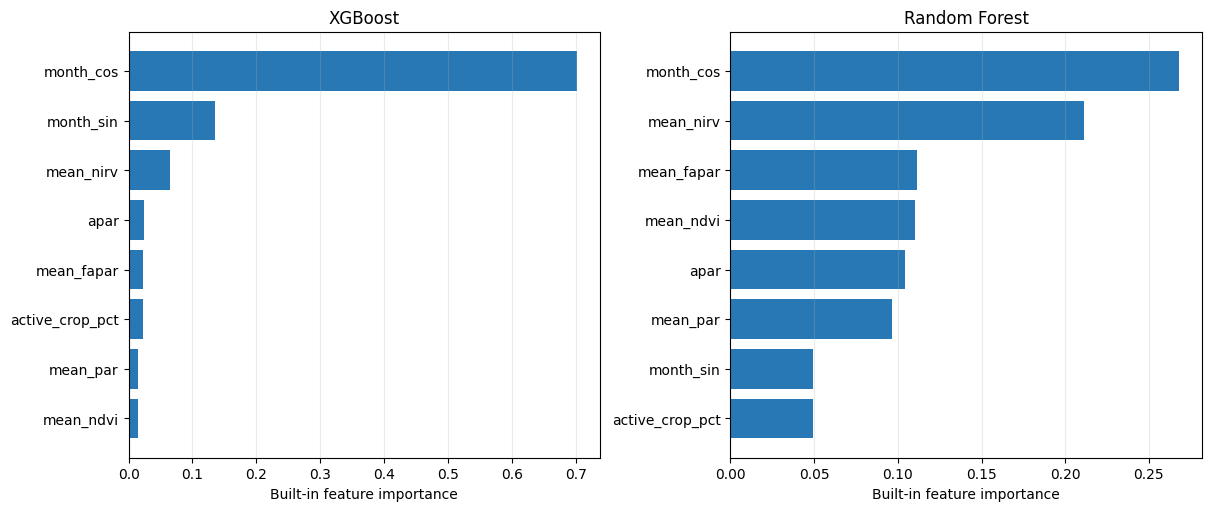

,model,feature,importance
15,Random Forest,month_cos,0.268125
9,Random Forest,mean_nirv,0.211353
10,Random Forest,mean_fapar,0.111293
8,Random Forest,mean_ndvi,0.110073
12,Random Forest,apar,0.104015
11,Random Forest,mean_par,0.096347
14,Random Forest,month_sin,0.049576
13,Random Forest,active_crop_pct,0.049219
7,XGBoost,month_cos,0.702486
6,XGBoost,month_sin,0.134556


In [11]:
importance = pd.concat(
    [
        pd.DataFrame(
            {
                'model': 'XGBoost',
                'feature': FEATURE_COLS,
                'importance': xgb_model.feature_importances_,
            }
        ),
        pd.DataFrame(
            {
                'model': 'Random Forest',
                'feature': FEATURE_COLS,
                'importance': rf_model.feature_importances_,
            }
        ),
    ],
    ignore_index=True,
)
importance.to_csv(OUTPUT_DIR / 'feature_importance.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, model_name in zip(axes, ['XGBoost', 'Random Forest']):
    subset = importance.loc[importance['model'] == model_name].sort_values(
        'importance'
    )
    ax.barh(subset['feature'], subset['importance'], color='#2878B5')
    ax.set_title(model_name)
    ax.set_xlabel('Built-in feature importance')
    ax.grid(axis='x', alpha=0.25)

FEATURE_PDF_PATH = OUTPUT_DIR / 'feature_importance_models.pdf'
fig.savefig(FEATURE_PDF_PATH, format='pdf', bbox_inches='tight')
plt.show()
display(importance.sort_values(['model', 'importance'], ascending=[True, False]))

## 12. Save Models and Run Configuration

In [12]:
xgb_model.save_model(str(OUTPUT_DIR / 'xgboost_pmeans_sif.json'))
joblib.dump(rf_model, OUTPUT_DIR / 'random_forest_pmeans_sif.joblib')

split_table = pd.concat(
    [
        train_df[['source_csv_row', 'Delta_Date']].assign(split='train'),
        test_df[['source_csv_row', 'Delta_Date']].assign(split='test'),
    ],
    ignore_index=True,
)
split_table.to_csv(OUTPUT_DIR / 'train_test_split.csv', index=False)

run_config = {
    'data_path': str(DATA_PATH),
    'target': TARGET_COL,
    'features': FEATURE_COLS,
    'split': 'single grouped 80/20 train-test split; grouped by Delta_Date',
    'seed': SEED,
    'n_train': len(train_df),
    'n_test': len(test_df),
    'metrics': metrics,
}
with (OUTPUT_DIR / 'run_config.json').open('w', encoding='utf-8') as file:
    json.dump(run_config, file, indent=2)

print('Saved outputs:')
for path in sorted(OUTPUT_DIR.iterdir()):
    print(' -', path)

Saved outputs:
 - /kaggle/working/pmeans_tabular_models/feature_importance.csv
 - /kaggle/working/pmeans_tabular_models/feature_importance_models.pdf
 - /kaggle/working/pmeans_tabular_models/observed_vs_predicted_density_random_forest.html
 - /kaggle/working/pmeans_tabular_models/observed_vs_predicted_density_random_forest.json
 - /kaggle/working/pmeans_tabular_models/observed_vs_predicted_density_xgboost.html
 - /kaggle/working/pmeans_tabular_models/observed_vs_predicted_density_xgboost.json
 - /kaggle/working/pmeans_tabular_models/random_forest_pmeans_sif.joblib
 - /kaggle/working/pmeans_tabular_models/run_config.json
 - /kaggle/working/pmeans_tabular_models/test_metrics.csv
 - /kaggle/working/pmeans_tabular_models/test_predictions.csv
 - /kaggle/working/pmeans_tabular_models/test_residual_distribution_random_forest.html
 - /kaggle/working/pmeans_tabular_models/test_residual_distribution_random_forest.json
 - /kaggle/working/pmeans_tabular_models/test_residual_distribution_xgboost.ht

## 13. Load the Prepared 2 km Pixel Sample

This section applies the fitted tabular models independently to crop-containing 20 m pixels. It is an illustrative spatial disaggregation because model fitting used footprint-mean predictors rather than pixel-level SIF labels.

In [17]:
# Change this to the mounted Kaggle dataset directory after upload.
KAGGLE_PIXEL_SAMPLE_DIR = Path(
    '/kaggle/input/datasets/vishalt11/tabular-eg1/tabular_2km_pixel_sample'
)
LOCAL_PIXEL_SAMPLE_DIR = Path(
    'data/pmeans_model_data/tabular_2km_pixel_sample'
)
PIXEL_SAMPLE_DIR = (
    KAGGLE_PIXEL_SAMPLE_DIR
    if KAGGLE_PIXEL_SAMPLE_DIR.exists()
    else LOCAL_PIXEL_SAMPLE_DIR
)

PIXEL_FEATURES_PATH = PIXEL_SAMPLE_DIR / 'pixel_features_2km_20m.csv'
PIXEL_GRID_PATH = PIXEL_SAMPLE_DIR / 'pixel_grid_2km_20m.npz'
PIXEL_METADATA_PATH = PIXEL_SAMPLE_DIR / 'sample_metadata.json'
SELECTED_ROW_PATH = PIXEL_SAMPLE_DIR / 'selected_sif_row.csv'

required_sample_paths = [
    PIXEL_FEATURES_PATH,
    PIXEL_GRID_PATH,
    PIXEL_METADATA_PATH,
    SELECTED_ROW_PATH,
]
missing_sample_paths = [
    str(path) for path in required_sample_paths if not path.exists()
]
if missing_sample_paths:
    raise FileNotFoundError(
        'Missing prepared pixel-sample files. Change '
        'KAGGLE_PIXEL_SAMPLE_DIR if necessary:\n'
        + '\n'.join(missing_sample_paths)
    )

pixel_df = pd.read_csv(PIXEL_FEATURES_PATH, low_memory=False)
pixel_grid = np.load(PIXEL_GRID_PATH, allow_pickle=False)
selected_sif_row = pd.read_csv(SELECTED_ROW_PATH, low_memory=False)
with PIXEL_METADATA_PATH.open('r', encoding='utf-8') as file:
    pixel_metadata = json.load(file)

prepared_feature_order = pixel_grid['feature_names'].astype(str).tolist()
if prepared_feature_order != FEATURE_COLS:
    raise ValueError(
        'Prepared feature order does not match the fitted models. '
        f'Prepared={prepared_feature_order}; model={FEATURE_COLS}'
    )

required_pixel_columns = [
    'pixel_row',
    'pixel_col',
    'predictable_pixel',
    'within_training_minmax',
    *FEATURE_COLS,
]
missing_pixel_columns = [
    column for column in required_pixel_columns if column not in pixel_df.columns
]
if missing_pixel_columns:
    raise ValueError(
        f'Pixel feature table is missing columns: {missing_pixel_columns}'
    )

for column in FEATURE_COLS:
    pixel_df[column] = pd.to_numeric(pixel_df[column], errors='coerce')


def boolean_column(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).to_numpy(dtype=bool)
    return (
        series.astype(str).str.strip().str.lower().isin(['true', '1', 'yes'])
        .to_numpy(dtype=bool)
    )


predictable = boolean_column(pixel_df['predictable_pixel'])
within_training_minmax = boolean_column(
    pixel_df['within_training_minmax']
)
pixel_matrix = pixel_df[FEATURE_COLS].to_numpy(dtype=np.float32)
finite_features = np.isfinite(pixel_matrix).all(axis=1)
inference_mask = predictable & finite_features

if inference_mask.sum() == 0:
    raise ValueError('No model-ready crop pixels were found in the sample')

print('Pixel sample directory:', PIXEL_SAMPLE_DIR)
print('Prepared feature order:', prepared_feature_order)
print('Grid shape:', pixel_metadata['grid_height'], 'x', pixel_metadata['grid_width'])
print('Model-ready crop pixels:', int(inference_mask.sum()), '/', len(pixel_df))
print(
    'Model-ready pixels inside every training min/max:',
    int((inference_mask & within_training_minmax).sum()),
)
display(selected_sif_row)

Pixel sample directory: /kaggle/input/datasets/vishalt11/tabular-eg1/tabular_2km_pixel_sample
Prepared feature order: ['mean_ndvi', 'mean_nirv', 'mean_fapar', 'mean_par', 'apar', 'active_crop_pct', 'month_sin', 'month_cos']
Grid shape: 100 x 100
Model-ready crop pixels: 9163 / 10000
Model-ready pixels inside every training min/max: 7644


,source_csv_row,Delta_Date,mgrs_tile,mgrs_tile_t,Latitude,Longitude,target_modis_sif,final_check_modis_sif,Lat_corner1,Lat_corner2,...,Lon_corner4,mean_ndvi,mean_nirv,mean_fapar,mean_par,apar,active_crop_pct,resolved_product_path,tile_center_distance_m,footprint_inside_2km_fraction
0,2926,2021-06-26,32UNA,T32UNA,50.079163,9.796936,0.565602,accept,50.073914,50.093628,...,9.807617,0.669316,0.26581,0.630667,135.566025,85.496973,1.0,data\geodes_wasp_zips\32UNA\2021\SENTINEL2X_20...,3512.338072,0.853651


## 14. Pixel-Wise XGBoost Prediction

In [18]:
pixel_df['predicted_sif_xgboost'] = np.nan

pixel_df.loc[inference_mask, 'predicted_sif_xgboost'] = (
    xgb_model.predict(pixel_matrix[inference_mask]).astype(np.float64)
)

grid_height = int(pixel_metadata['grid_height'])
grid_width = int(pixel_metadata['grid_width'])
expected_rows = grid_height * grid_width
if len(pixel_df) != expected_rows:
    raise ValueError(
        f'Expected {expected_rows} pixel rows, found {len(pixel_df)}'
    )

pixel_df = pixel_df.sort_values(
    ['pixel_row', 'pixel_col'],
    kind='stable',
).reset_index(drop=True)

xgb_sif_map = pixel_df['predicted_sif_xgboost'].to_numpy().reshape(
    grid_height,
    grid_width,
)
raw_ndvi_map = pixel_grid['raw_ndvi_20m'].astype(np.float32)
footprint_mask = pixel_grid['footprint_mask'].astype(np.float32)

pixel_predictions_path = OUTPUT_DIR / 'tabular_2km_pixel_predictions.csv'
pixel_df.to_csv(pixel_predictions_path, index=False)

np.savez_compressed(
    OUTPUT_DIR / 'tabular_2km_predicted_sif_map_xgboost.npz',
    xgboost_sif=xgb_sif_map.astype(np.float32),
    raw_ndvi=raw_ndvi_map,
    footprint_mask=footprint_mask,
    inference_mask=inference_mask.reshape(grid_height, grid_width),
    feature_names=np.asarray(FEATURE_COLS),
)

print('Saved pixel predictions:', pixel_predictions_path)
print(
    'XGBoost predicted SIF range:',
    float(np.nanmin(xgb_sif_map)),
    float(np.nanmax(xgb_sif_map)),
)

Saved pixel predictions: /kaggle/working/pmeans_tabular_models/tabular_2km_pixel_predictions.csv
XGBoost predicted SIF range: 0.2742973268032074 0.6848956942558289


## 15. Example Predicted SIF Map

The grey areas are pixels outside the crop-only inference mask.

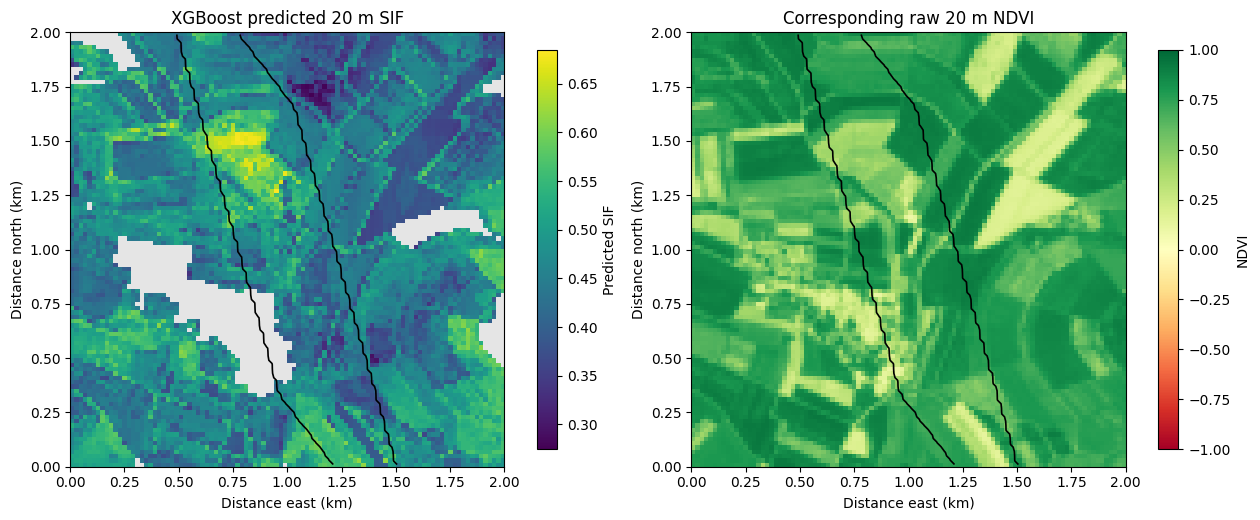

Saved XGBoost map PDF: /kaggle/working/pmeans_tabular_models/example_predicted_sif_map_and_ndvi_xgboost.pdf
Saved XGBoost map PNG: /kaggle/working/pmeans_tabular_models/example_predicted_sif_map_and_ndvi_xgboost.png


In [20]:
finite_predictions = xgb_sif_map[np.isfinite(xgb_sif_map)]
if len(finite_predictions) == 0:
    raise ValueError('The XGBoost predicted SIF map is entirely missing')

sif_vmin = float(np.min(finite_predictions))
sif_vmax = float(np.max(finite_predictions))
if math.isclose(sif_vmin, sif_vmax):
    sif_vmax = sif_vmin + 1e-6

sif_cmap = plt.get_cmap('viridis').copy()
sif_cmap.set_bad('#E5E5E5')

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(
    xgb_sif_map,
    origin='upper',
    cmap=sif_cmap,
    vmin=sif_vmin,
    vmax=sif_vmax,
    interpolation='nearest',
)
ax.set_aspect('equal')
ax.set_axis_off()
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

svg_path = OUTPUT_DIR / 'example_predicted_sif_map_and_ndvi_xgboost.svg'
fig.savefig(
    svg_path,
    format='svg',
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()
plt.close(fig)

print('Saved XGBoost SIF map SVG:', svg_path)